# Explore & Verify the Vector DB (ChromaDB)

This notebook verifies the RAG pipeline is working correctly:
1. Check ChromaDB collection stats
2. Inspect stored chunks and embeddings
3. Test retrieval queries against known variances
4. Validate that the right context is returned for each planted anomaly

In [2]:
import sys, os
os.chdir(os.path.join(os.path.dirname(os.path.abspath('.')), ''))
sys.path.insert(0, 'src')

import chromadb
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from rag_pipeline import (
    FinancialRAG, load_rag_documents, chunk_document,
    COLLECTION_NAME, EMBED_MODEL, CHROMA_DIR, RAG_DOCS_DIR, TOP_K
)

print(f"Working dir: {os.getcwd()}")
print(f"ChromaDB dir: {CHROMA_DIR}")
print(f"Embedding model: {EMBED_MODEL}")
print(f"Collection: {COLLECTION_NAME}")

/Users/Cherry/Projects/ai-variance-analyst/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/Cherry/Projects/ai-variance-analyst/venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Working dir: /Users/Cherry/Projects/ai-variance-analyst
ChromaDB dir: data/chroma_db
Embedding model: all-MiniLM-L6-v2
Collection: novatech_financial_context


## 1. Initialize RAG & Inspect Collection

In [3]:
# Initialize the RAG pipeline (builds vector store if needed)
rag = FinancialRAG(docs_dir=RAG_DOCS_DIR, persist_dir=CHROMA_DIR)

# Connect directly to ChromaDB to inspect
client = chromadb.PersistentClient(path=CHROMA_DIR)
collection = client.get_collection(COLLECTION_NAME)

print(f"Collection name: {collection.name}")
print(f"Total chunks stored: {collection.count()}")

  Loaded 57 chunks from 5 documents
  ✅ Loaded existing vector store (57 chunks)
Collection name: novatech_financial_context
Total chunks stored: 57


In [4]:
# Get all data from the collection
all_data = collection.get(include=["documents", "metadatas", "embeddings"])

print(f"Number of documents: {len(all_data['documents'])}")
print(f"Number of embeddings: {len(all_data['embeddings'])}")
print(f"Embedding dimension: {len(all_data['embeddings'][0])}")

# Check sources
sources = [m['source'] for m in all_data['metadatas']]
source_counts = pd.Series(sources).value_counts()
print(f"\nChunks per source document:")
print(source_counts.to_string())

Number of documents: 57
Number of embeddings: 57
Embedding dimension: 384

Chunks per source document:
account_definitions          13
historical_variances         13
budget_assumptions_fy2024    13
company_overview             10
seasonality_patterns          8


## 2. Inspect Chunk Quality

Check that chunks are reasonable — not too short, not cutting mid-sentence badly.

In [5]:
# Chunk length distribution
chunk_lengths = [len(doc) for doc in all_data['documents']]

print(f"Chunk length stats:")
print(f"  Min: {min(chunk_lengths)} chars")
print(f"  Max: {max(chunk_lengths)} chars")
print(f"  Mean: {np.mean(chunk_lengths):.0f} chars")
print(f"  Median: {np.median(chunk_lengths):.0f} chars")

# Show a few sample chunks
print("\n" + "="*80)
print("SAMPLE CHUNKS")
print("="*80)
for i in [0, len(all_data['documents'])//2, -1]:
    print(f"\n--- Chunk {i} | Source: {all_data['metadatas'][i]['source']} | ID: {all_data['ids'][i]} ---")
    print(all_data['documents'][i][:300] + "...")

Chunk length stats:
  Min: 57 chars
  Max: 600 chars
  Mean: 572 chars
  Median: 600 chars

SAMPLE CHUNKS

--- Chunk 0 | Source: seasonality_patterns | ID: seasonality_patterns_0 ---
# Seasonality Patterns & Business Calendar — NovaTech Solutions Inc.

---

## Annual Revenue Seasonality

NovaTech's revenue follows a predictable back-half weighted pattern:

| Quarter | Revenue Mix | Key Driver |
|---|---|---|
| Q1 | 21% of annual | Slow procurement; new logos from Q4 pipeline beg...

--- Chunk 28 | Source: account_definitions | ID: account_definitions_10 ---
ernal tools (Salesforce, Slack, GitHub, etc.)  
**Normal Behavior:** Relatively fixed; annual contracts create lumpiness in renewal months.

### Account 6006 — Depreciation & Amortization
**Nature:** Non-cash expense. Depreciation of hardware and amortization of capitalized software.  
**Normal Beha...

--- Chunk -1 | Source: budget_assumptions_fy2024 | ID: budget_assumptions_fy2024_12 ---
nce planning = cost spike risk.
4. **Headco

## 3. Test Retrieval Against Known Variances

The mock data has these planted anomalies. The RAG should return relevant context for each.

In [6]:
# The planted anomalies from generate_data.py
test_cases = [
    {
        "name": "Marketing overspend Q3 (brand campaign)",
        "account": "Marketing & Advertising",
        "department": "Marketing",
        "period": "2024-07",
        "variance_pct": 0.42,
        "expect_keywords": ["campaign", "NovaSummit", "marketing", "Q3"],
    },
    {
        "name": "SaaS revenue miss Q3 (churn)",
        "account": "Product Revenue - SaaS",
        "department": "Sales",
        "period": "2024-08",
        "variance_pct": -0.21,
        "expect_keywords": ["churn", "ARR", "revenue", "customer"],
    },
    {
        "name": "Cloud infra spike (migration)",
        "account": "Cloud Infrastructure Costs",
        "department": "Engineering",
        "period": "2024-10",
        "variance_pct": 0.31,
        "expect_keywords": ["infrastructure", "cloud", "migration", "compute"],
    },
    {
        "name": "T&E spike - Sales SKO (April)",
        "account": "Travel & Entertainment",
        "department": "Sales",
        "period": "2024-04",
        "variance_pct": 0.55,
        "expect_keywords": ["SKO", "travel", "kickoff", "sales"],
    },
    {
        "name": "Legal fees spike (contract negotiation)",
        "account": "Legal & Professional Fees",
        "department": "G&A",
        "period": "2024-11",
        "variance_pct": 0.62,
        "expect_keywords": ["legal", "contract", "counsel", "professional"],
    },
    {
        "name": "PS Revenue beat Q4",
        "account": "Professional Services Revenue",
        "department": "Sales",
        "period": "2024-10",
        "variance_pct": 0.24,
        "expect_keywords": ["implementation", "services", "backlog", "enterprise"],
    },
]

print(f"Running {len(test_cases)} retrieval tests...\n")

Running 6 retrieval tests...



In [7]:
# Run each test case and check if relevant context is returned
results = []

for tc in test_cases:
    context = rag.retrieve_for_variance(
        tc["account"], tc["department"], tc["period"], tc["variance_pct"]
    )
    
    # Check which expected keywords appear in the retrieved context
    context_lower = context.lower()
    found = [kw for kw in tc["expect_keywords"] if kw.lower() in context_lower]
    missed = [kw for kw in tc["expect_keywords"] if kw.lower() not in context_lower]
    score = len(found) / len(tc["expect_keywords"]) * 100
    
    results.append({
        "test": tc["name"],
        "keywords_found": ", ".join(found),
        "keywords_missed": ", ".join(missed) if missed else "-",
        "score": f"{score:.0f}%",
        "context_length": len(context),
    })
    
    print(f"{'PASS' if score >= 50 else 'FAIL'} | {tc['name']}")
    print(f"     Keywords found: {found}")
    if missed:
        print(f"     Keywords missed: {missed}")
    print()

results_df = pd.DataFrame(results)
results_df

PASS | Marketing overspend Q3 (brand campaign)
     Keywords found: ['campaign', 'marketing', 'Q3']
     Keywords missed: ['NovaSummit']

PASS | SaaS revenue miss Q3 (churn)
     Keywords found: ['churn', 'ARR', 'revenue', 'customer']

PASS | Cloud infra spike (migration)
     Keywords found: ['infrastructure', 'cloud', 'compute']
     Keywords missed: ['migration']

PASS | T&E spike - Sales SKO (April)
     Keywords found: ['SKO', 'travel', 'kickoff', 'sales']

PASS | Legal fees spike (contract negotiation)
     Keywords found: ['legal', 'contract']
     Keywords missed: ['counsel', 'professional']

PASS | PS Revenue beat Q4
     Keywords found: ['implementation', 'services', 'enterprise']
     Keywords missed: ['backlog']



,test,keywords_found,keywords_missed,score,context_length
0,Marketing overspend Q3 (brand campaign),"campaign, marketing, Q3",NovaSummit,75%,3180
1,SaaS revenue miss Q3 (churn),"churn, ARR, revenue, customer",-,100%,3186
2,Cloud infra spike (migration),"infrastructure, cloud, compute",migration,75%,3193
3,T&E spike - Sales SKO (April),"SKO, travel, kickoff, sales",-,100%,3186
4,Legal fees spike (contract negotiation),"legal, contract","counsel, professional",50%,3178
5,PS Revenue beat Q4,"implementation, services, enterprise",backlog,75%,3181


## 4. Deep Dive: Inspect a Single Retrieval

Look at exactly what chunks are returned for one query, with similarity scores.

In [8]:
# Pick the marketing overspend case for a deep dive
model = SentenceTransformer(EMBED_MODEL)

query = "Marketing Advertising overspend variance budget actual 2024-07 driver explanation seasonality"
query_embedding = model.encode([query]).tolist()

results = collection.query(
    query_embeddings=query_embedding,
    n_results=5,
    include=["documents", "metadatas", "distances"],
)

print(f"Query: {query}\n")
print("Retrieved chunks (nearest first):")
print("=" * 80)
for i in range(len(results['documents'][0])):
    doc = results['documents'][0][i]
    source = results['metadatas'][0][i]['source']
    distance = results['distances'][0][i]
    similarity = 1 - distance  # ChromaDB uses L2 by default, but cosine if configured
    
    print(f"\n--- Rank {i+1} | Source: {source} | Distance: {distance:.4f} ---")
    print(doc[:400])
    print()

Query: Marketing Advertising overspend variance budget actual 2024-07 driver explanation seasonality

Retrieved chunks (nearest first):

--- Rank 1 | Source: account_definitions | Distance: 0.9889 ---
Signal:** Commission overrun is a positive leading indicator for SaaS revenue (bookings precede revenue recognition).

### Account 6003 — Marketing & Advertising
**Nature:** External spend on demand generation, brand awareness, events, digital advertising.  
**Normal Behavior:** Highly seasonal. H2-heavy with major investment in Q3 (user conference, brand campaign).  
**Common Variance Drivers:** 


--- Rank 2 | Source: account_definitions | Distance: 1.0077 ---
3 marketing variances of up to +40% have been explicitly planned for the annual conference.

### Account 6004 — Travel & Entertainment
**Nature:** Employee travel (flights, hotels), customer entertainment, meals.  
**Normal Behavior:** Lumpy; peaks in April (SKO), Q2/Q4 (customer events), and whenever executive travel is elevated.

## 5. Embedding Space Visualization

Reduce embeddings to 2D with PCA to see if documents cluster by source.

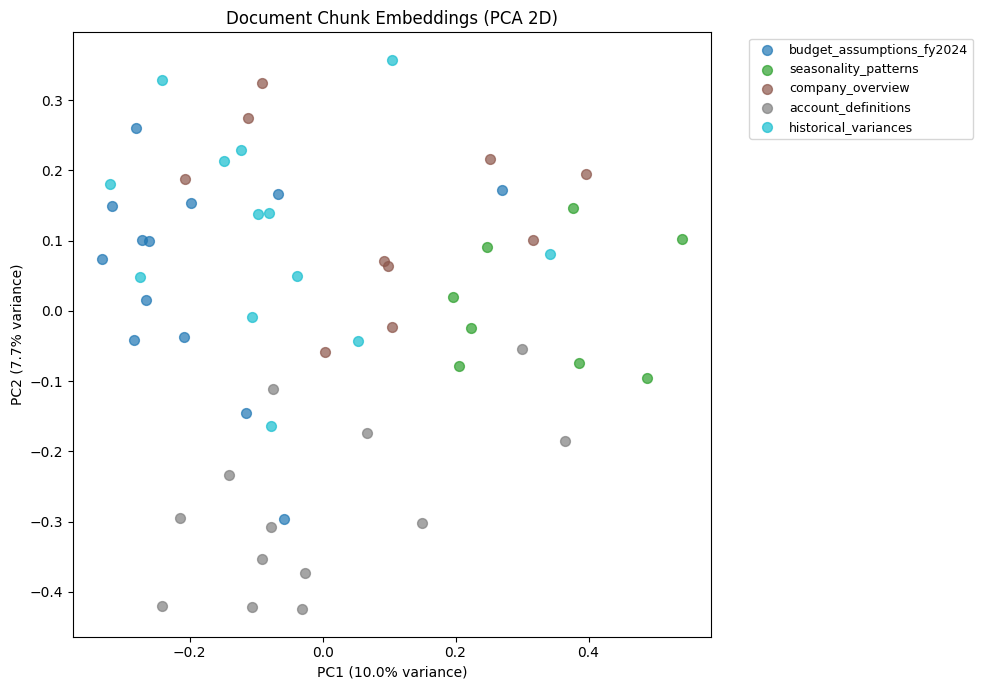

PCA explained variance: 17.7%


In [10]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

embeddings = np.array(all_data['embeddings'])
sources = [m['source'] for m in all_data['metadatas']]

# PCA to 2D
pca = PCA(n_components=2)
coords = pca.fit_transform(embeddings)

plt.figure(figsize=(10, 7))
unique_sources = list(set(sources))
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_sources)))

for source, color in zip(unique_sources, colors):
    mask = [s == source for s in sources]
    plt.scatter(coords[mask, 0], coords[mask, 1], label=source, alpha=0.7, s=50, color=color)

plt.title('Document Chunk Embeddings (PCA 2D)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.1%}")

## 6. Retrieval Comparison: Vector Search vs Keyword Fallback

Compare what the vector DB returns vs the keyword fallback to validate embeddings add value.

In [11]:
from rag_pipeline import keyword_search_fallback

docs = load_rag_documents(RAG_DOCS_DIR)

# Test with a semantically rich query (embeddings should shine here)
semantic_query = "Why did cloud costs increase unexpectedly in Q4?"

# Vector retrieval
vector_context = rag.retrieve(semantic_query, top_k=3)

# Keyword fallback
keyword_results = keyword_search_fallback(semantic_query, docs, top_k=3)
keyword_context = "\n---\n".join([r['text'][:200] for r in keyword_results])

print("VECTOR RETRIEVAL (top 3):")
print("=" * 80)
print(vector_context[:800])

print("\n\nKEYWORD FALLBACK (top 3):")
print("=" * 80)
print(keyword_context[:800])

print("\n\n---")
print("Vector search should return more semantically relevant chunks,")
print("especially for queries that don't use exact keywords from the docs.")

  Loaded 57 chunks from 5 documents
VECTOR RETRIEVAL (top 3):
[Source: historical_variances]
.

---

## FY2022 Variance Commentary (Selected)

### Full Year 2022 — Cloud Infrastructure (Account 5001)
**Variance:** +$156K / +15.5% over budget  
**Explanation:** Customer growth exceeded plan by 18% in terms of data volume processed. The rapid onboarding of 3 enterprise customers in Q3 (originally planned for Q4) caused infrastructure provisioning to run ahead of plan. Reserved instance coverage was at 65% vs 80% target, resulting in higher on-demand pricing for the excess compute. This was a high-quality variance (revenue overperformance drove cost overperformance).  
**Lesson:** Infras

---

[Source: company_overview]
f the year
- Q3 historically shows the highest marketing variance due to event timing
- **Known Issue:** A large financial services cus


KEYWORD FALLBACK (top 3):
**Explanation:** Board-directed external counsel engagement for Series C preliminary materials. While the rou

## 7. Edge Cases

Test queries that are tricky — vague, off-topic, or ambiguous.

In [12]:
edge_cases = [
    "What is the meaning of life?",                          # Completely off-topic
    "revenue",                                               # Single vague word
    "Why are we spending so much money on everything?",      # Broad and unfocused
    "Q4 2024 forecast risk headcount hiring plan",           # Multiple relevant topics
]

for query in edge_cases:
    context = rag.retrieve(query, top_k=2)
    sources_found = [line.split("Source: ")[1].split("]")[0] 
                     for line in context.split("\n") if "[Source:" in line]
    
    print(f"Query: \"{query}\"")
    print(f"  Sources: {sources_found}")
    print(f"  Context length: {len(context)} chars")
    print(f"  Preview: {context[:150].replace(chr(10), ' ')}...")
    print()

Query: "What is the meaning of life?"
  Sources: ['account_definitions', 'company_overview']
  Context length: 1264 chars
  Preview: [Source: account_definitions] eeding new business or downsell.   **Common Variance Drivers:** Customer churn, deal slippage, downsell at renewal, pric...

Query: "revenue"
  Sources: ['company_overview', 'account_definitions']
  Context length: 1264 chars
  Preview: [Source: company_overview] t Makes Revenue Go Up 1. New Enterprise logos closed by Sales team (2–4 month sales cycle) 2. Expansion within existing acc...

Query: "Why are we spending so much money on everything?"
  Sources: ['budget_assumptions_fy2024', 'budget_assumptions_fy2024']
  Context length: 1279 chars
  Preview: [Source: budget_assumptions_fy2024] s expected and budgeted due to SKO. Unplanned T&E spikes outside of April should be investigated.  ### Software & ...

Query: "Q4 2024 forecast risk headcount hiring plan"
  Sources: ['historical_variances', 'historical_variances']
  Context

## Summary

**What to check:**
- Section 1: Collection exists and has the expected number of chunks
- Section 3: All 6 planted anomalies return relevant context (score >= 50%)
- Section 4: Top-ranked chunks are actually about the queried topic
- Section 5: Chunks from the same document cluster together (good embeddings)
- Section 6: Vector search returns better results than keyword fallback for semantic queries
- Section 7: Off-topic queries still return *something* (graceful degradation, no crashes)